In [12]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pycocotools.coco import COCO

data_dir = '../data/coco'
data_type = 'train2017'
ann_file = f'{data_dir}/annotations/instances_{data_type}.json'
img_dir = f'{data_dir}/images/{data_type}'

# Load COCO API
print("Đang tải dữ liệu annotations...")
coco = COCO(ann_file)

Đang tải dữ liệu annotations...
loading annotations into memory...
Done (t=4.62s)
creating index...
index created!


In [13]:

img_ids = coco.getImgIds()
ann_ids = coco.getAnnIds()
cat_ids = coco.getCatIds()

print(f"Tổng số lượng ảnh (Images): {len(img_ids)}")
print(f"Tổng số lượng vật thể được gán nhãn (Annotations): {len(ann_ids)}")
print(f"Tổng số lượng phân lớp (Categories/Classes): {len(cat_ids)}")

# Show some example classes
cats = coco.loadCats(cat_ids)
cat_names = [cat['name'] for cat in cats]
print(f"\nMột số class ví dụ: {cat_names[:10]}")

Tổng số lượng ảnh (Images): 118287
Tổng số lượng vật thể được gán nhãn (Annotations): 860001
Tổng số lượng phân lớp (Categories/Classes): 80

Một số class ví dụ: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


/tmp/ipykernel_11022/1835683046.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Category', data=df_counts.head(20), palette='viridis')


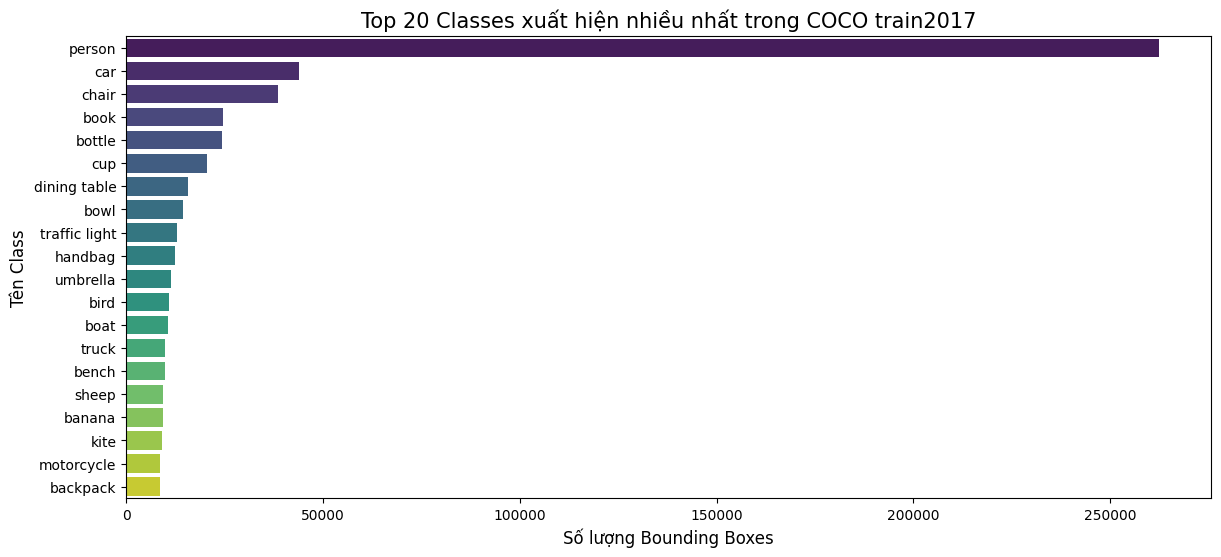

/tmp/ipykernel_11022/1835683046.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Category', data=df_counts.tail(20), palette='magma')


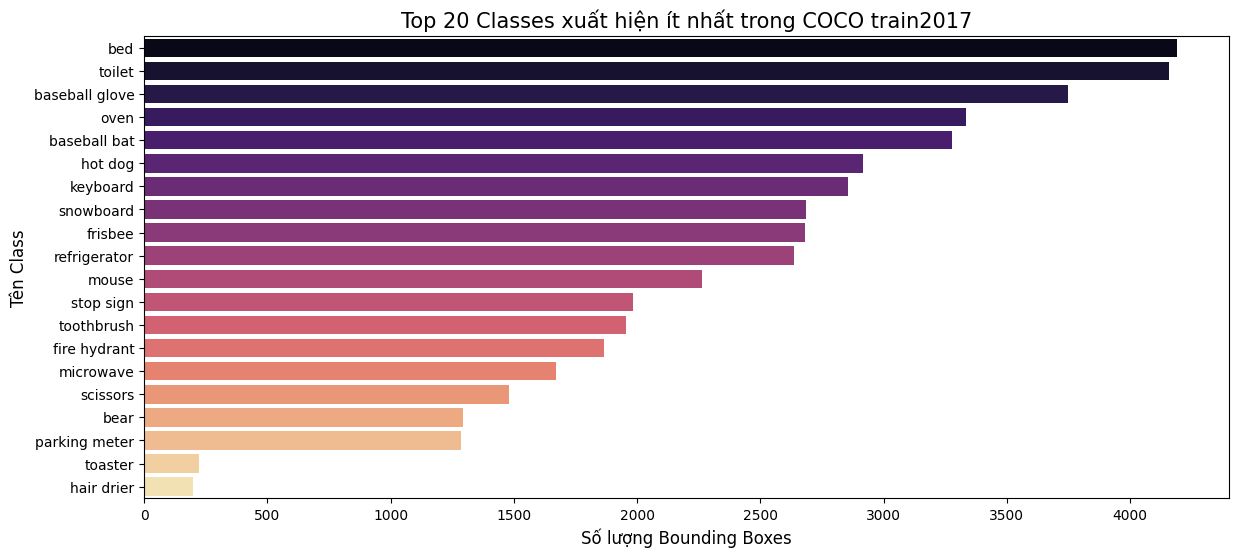

In [14]:
# Count annotations per category
ann_counts = []
for cat_id in cat_ids:
    ann_ids_per_cat = coco.getAnnIds(catIds=[cat_id])
    cat_name = coco.loadCats(cat_id)[0]['name']
    ann_counts.append({'Category': cat_name, 'Count': len(ann_ids_per_cat)})
# Convert to DataFrame
df_counts = pd.DataFrame(ann_counts).sort_values(by='Count', ascending=False)

# Most 20 common classes
plt.figure(figsize=(14, 6))
sns.barplot(x='Count', y='Category', data=df_counts.head(20), palette='viridis')
plt.title('Top 20 Classes xuất hiện nhiều nhất trong COCO train2017', fontsize=15)
plt.xlabel('Số lượng Bounding Boxes', fontsize=12)
plt.ylabel('Tên Class', fontsize=12)
plt.show()

# Least 20 common classes
plt.figure(figsize=(14, 6))
sns.barplot(x='Count', y='Category', data=df_counts.tail(20), palette='magma')
plt.title('Top 20 Classes xuất hiện ít nhất trong COCO train2017', fontsize=15)
plt.xlabel('Số lượng Bounding Boxes', fontsize=12)
plt.ylabel('Tên Class', fontsize=12)
plt.show()

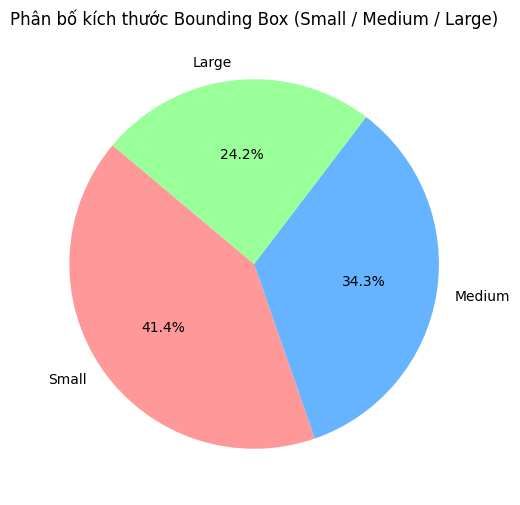

In [15]:
# Small (< 32^2), Medium (32^2 đến 96^2), Large (> 96^2)
areas = [ann['area'] for ann_id in ann_ids for ann in coco.loadAnns(ann_id)]

small = sum(1 for a in areas if a < 32**2)
medium = sum(1 for a in areas if 32**2 <= a <= 96**2)
large = sum(1 for a in areas if a > 96**2)

labels = ['Small', 'Medium', 'Large']
sizes = [small, medium, large]
colors = ['#ff9999','#66b3ff','#99ff99']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Phân bố kích thước Bounding Box (Small / Medium / Large)')
plt.show()

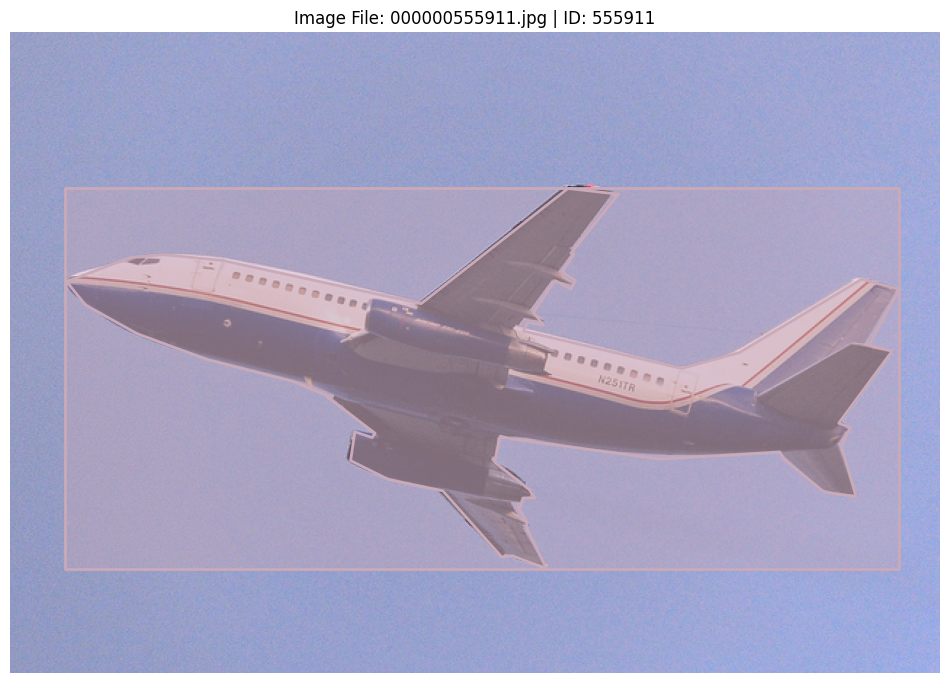

In [17]:
import random

random_img_id = random.choice(img_ids)
img_info = coco.loadImgs(random_img_id)[0]
img_path = os.path.join(img_dir, img_info['file_name'])

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

ann_ids_img = coco.getAnnIds(imgIds=img_info['id'])
anns = coco.loadAnns(ann_ids_img)

plt.figure(figsize=(12, 10))
plt.imshow(image)
plt.axis('off')
coco.showAnns(anns, draw_bbox=True)
plt.title(f"Image File: {img_info['file_name']} | ID: {img_info['id']}")
plt.show()